<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/supervised/Supervised_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import scipy.io as sio
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/Supervised/Datasets/dataset"

# explore the dataset

In [8]:
# explore the dataset
for ndataset in range(1, 5):
  dataset = sio.loadmat(f'{dataset_path}{ndataset}.mat')
  print(f"""Data {ndataset}: {dataset['data'][:3]}
  Labels: {dataset['labels'][:2]}
  """)

Data 1: [[0.18132269 0.17706942]
 [0.29716829 0.16354253]
 [0.27883425 0.2405079 ]]
  Labels: [[1]
 [1]]
  
Data 2: [[0.38745019 0.43470617]
 [0.17075676 0.13699772]
 [0.16240446 0.04058942]]
  Labels: [[1]
 [1]]
  
Data 3: [[ 0.14196814  0.13678729]
 [ 0.24998859  0.13741733]
 [ 0.10391464 -0.01266325]]
  Labels: [[1]
 [1]]
  
Data 4: [[ 0.24472039 -0.59760684]
 [ 0.59999055 -0.6002798 ]
 [-0.00403589 -0.00990386]]
  Labels: [[1]
 [1]]
  


In [9]:
dataset['data']

array([[ 0.24472039, -0.59760684],
       [ 0.59999055, -0.6002798 ],
       [-0.00403589, -0.00990386],
       ...,
       [ 0.94690674,  1.32727933],
       [-1.26308963, -1.4394436 ],
       [ 0.82838682, -1.17415239]])

In [10]:
data0 = dataset['data']
label0 = dataset['labels']

In [184]:
label0[297: 303]

array([[1],
       [1],
       [1],
       [2],
       [2],
       [2]], dtype=uint8)

In [9]:
data0.shape

(600, 2)

# Creat First 5x2 Cross Validation



### 1️⃣ Create a **5×2 Cross Validation (t=5, k=2)** on one of the dataset
**Workflow:**

For each of the t repetitions (t = 5):

1. **Split dataset in half** (stratified by class) → train/test

> 🔑 **Stratified = “keep class proportions the same”**

> * If your dataset has 60% class 1 and 40% class 2
> * Stratified split makes sure **train and test sets also have 60% class 1 and 40% class 2**
> * This avoids **biased training or testing**

2. **Train SVM on first half**, predict on second → `accuracy1`
3. **Swap halves** → train on second half, predict on first → `accuracy2`
4. **Average both accuracies** → `accuracy = (accuracy1 + accuracy2)/2`
5. **Append `accuracy` to `accuracy_times`**

After the loop:

```
accuracy_times = [accuracy_split1, accuracy_split2, ..., accuracy_split5]
```


In [114]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC

all_accuracy_times =[]
confusion_matrixes = [] # this is not part of the task
# loop through 5 time
for itime in range(5):
  # 1. split dataset in half (stratified by class)
  # stratified -> each set has the same class ratio as the full dataset
  X_train, X_test, y_train, y_test = train_test_split(data0, label0, test_size=0.5, random_state=42, stratify=label0, shuffle=True)

  # 2.1 Train SVM on first half
  # SVM = draws the best dividing line (or plane) with maximum space between classes.
  svm_linear_model = SVC(kernel='linear', C=1.0)
  # train
  svm_linear_model.fit(X_train, y_train.ravel())
  # 2.2predict on second → accuracy1
  y_pred = svm_linear_model.predict(X_test)
  accuracy1 = accuracy_score(y_test.ravel(), y_pred)
  # Extra
  cm1 = confusion_matrix(y_test.ravel(), y_pred)
  confusion_matrixes.append(cm1)

  # 3.1 Swap halves → train on second half
  svm_linear_model.fit(X_test, y_test.ravel())
  # 3.2 Predict on first → accuracy2
  y_pred2 = svm_linear_model.predict(X_train)
  accuracy2 = accuracy_score(y_train.ravel(), y_pred2)
  # Extra
  cm2 = confusion_matrix(y_train.ravel(), y_pred2)
  confusion_matrixes.append(cm2)

  # 4. Average both accuracies → accuracy = (accuracy1 + accuracy2)/2
  accuracy = (accuracy1 + accuracy2)/2

  # 5. Append accuracy to accuracy_times
  all_accuracy_times.append(accuracy)


In [115]:
X_train.shape, y_train.shape, all_accuracy_times, confusion_matrixes[:1]

((300, 2),
 (300, 1),
 [0.58, 0.58, 0.58, 0.58, 0.58],
 [array([[118,  32],
         [ 91,  59]])])

Plot accuracy across the 5 runs

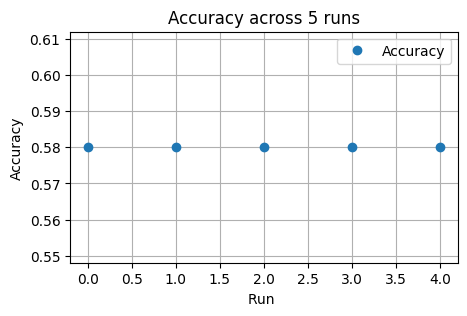

In [116]:
import matplotlib.pyplot as plt
mean_acc = np.mean(all_accuracy_times)
std_acc = np.std(all_accuracy_times)
plt.figure(figsize=(5, 3))
# plt.errorbar(1, mean_acc, yerr=std_acc, fmt='o', capsize=5, mec='green')
plt.plot(all_accuracy_times, 'o', label="Accuracy")
plt.title("Accuracy across 5 runs")
plt.xlabel("Run ")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

Plot the dataset with the SVM decision boundary

Text(0, 0.5, 'Feature 2')

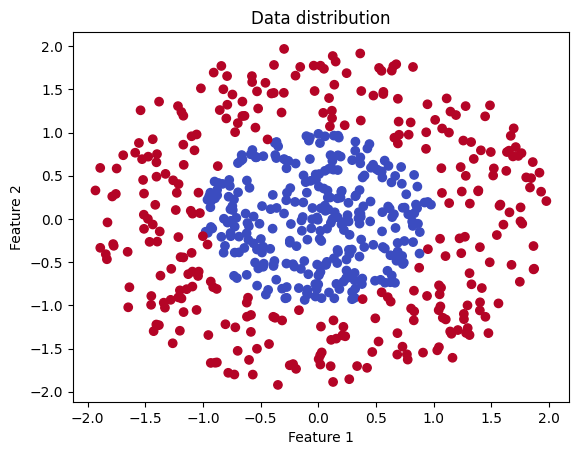

In [117]:
# Plot the dataset with the SVM decision boundary
plt.scatter(data0[:, 0], data0[:, 1], c=label0, cmap="coolwarm")
plt.title("Data distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")


### 2️⃣ Create a **5×2 Cross Validation (t=5, k=2) only SVM alogrithm `❗ but not using sklearn`**  packages
**Index selection approach:**

 1. Create **index lists**

 2. Use indexes to select rows

 3. Apply same indexes to **data and labels**


In [118]:
def get_dataset_indexes(label):
  """
  Select indexes → train/test using index seletion
  """
  training_index = []
  testing_index = []
  # Index selection to data & labels
  for nclass in [1, 2]:
    # Create index list
    index_list = np.where(label.ravel() == nclass)[0]
    np.random.shuffle(index_list)
    # split indexs
    split = len(index_list)//2
    # Use indexes to select rows
    training_index.extend(index_list[:split])
    testing_index.extend(index_list[split:])
  return training_index, testing_index

In [119]:
# 1. Split dataset in half (stratified by class) → train/test
def train_model(t=5, dataset=[], label=[]):
  """
  training the model
  """
  accuracy_times =[]
  for ntimes in range(t):
    # Get the training and testing index
    training_index, testing_index = get_dataset_indexes(label)

    # Get the training and testing dataset
    train_dataset = dataset[training_index, :]
    train_label = label[training_index].ravel()
    test_dataset = dataset[testing_index, :]
    test_label = label[testing_index].ravel()

    # 2.1 Train SVM on first half
    svm_linear_model_2 = SVC(kernel='linear', C=1.0)
    svm_linear_model_2.fit(train_dataset, train_label)
    # 2.2 predict on second
    y_pred1 = svm_linear_model_2.predict(test_dataset)
    # 2. 3 → accuracy1
    accuracy1 = np.sum(y_pred1 == test_label)/len(test_label)

    # 3. Swap halves → train on second half, predict on first → accuracy2
    svm_linear_model_2.fit(test_dataset, test_label)
    y_pred2 = svm_linear_model_2.predict(train_dataset)
    accuracy2 = np.sum(y_pred2 == train_label)/len(train_label)

    # 4. Average both accuracies → accuracy = (accuracy1 + accuracy2)/2
    accuracy = (accuracy1 + accuracy2)/2

    # 5. Append accuracy to accuracy_times
    accuracy_times.append(accuracy)
  return accuracy_times

In [120]:
# Train SVM model for all datasets
accuracy1_5x2 = []
repetitions = 5
for ndataset in range(1, 5):
  dataset = sio.loadmat(f"{dataset_path}{ndataset}.mat")
  data = dataset['data']
  label = dataset['labels']
  # train model
  accuracy = train_model(repetitions, data, label)
  accuracy1_5x2.append(accuracy)
accuracy1_5x2

[[np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)],
 [np.float64(0.8933333333333333),
  np.float64(0.88),
  np.float64(0.8833333333333333),
  np.float64(0.8833333333333333),
  np.float64(0.8833333333333333)],
 [np.float64(0.6666666666666666),
  np.float64(0.6666666666666666),
  np.float64(0.6666666666666666),
  np.float64(0.6666666666666666),
  np.float64(0.6666666666666666)],
 [np.float64(0.5566666666666666),
  np.float64(0.5416666666666667),
  np.float64(0.5866666666666667),
  np.float64(0.5433333333333333),
  np.float64(0.565)]]

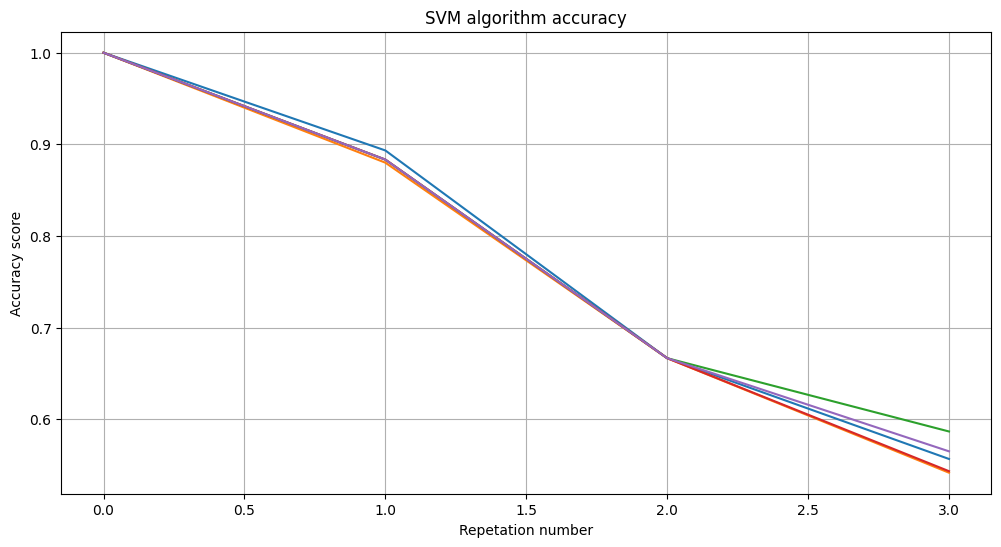

In [121]:
# Plot the SVM accuracies
plt.figure(figsize=(12, 6))
plt.plot(accuracy1_5x2)
plt.title("SVM algorithm accuracy")
plt.xlabel("Repetation number")
plt.ylabel("Accuracy score")
plt.grid()

### 2️⃣ Create a **5×2 Cross Validation (t=5, k=2) only the following**  algorithm
Create and train the model on the same training and testing dataset at the same time to undrestand whhich algorithm works better

1. **SVM**
2. **RBF**
3. **Decision Tree Classifier (GINI)**
4. **K-Neighbors Classifier (MINKOWSKI)**

In [122]:
def train_multi_model(t=5, dataset=None, label=None, models=None):
  """
  training the mulit model
  """
  accuracy_times = {name: [] for name in models.keys() }
  for ntimes in range(t):
    # Get the training and testing index
    training_index, testing_index = get_dataset_indexes(label)

    # Get the training and testing dataset
    train_dataset = dataset[training_index, :]
    train_label = label[training_index].ravel()
    test_dataset = dataset[testing_index, :]
    test_label = label[testing_index].ravel()

    # 2.1 Train SVM on first half
    for name, model in models.items():

      model.fit(train_dataset, train_label)
      # 2.2 predict on second
      y_pred1 = model.predict(test_dataset)
      # 2. 3 → accuracy1
      accuracy1 = np.sum(y_pred1 == test_label)/len(test_label)

      # 3. Swap halves → train on second half, predict on first → accuracy2
      model.fit(test_dataset, test_label)
      y_pred2 = model.predict(train_dataset)
      accuracy2 = np.sum(y_pred2 == train_label)/len(train_label)

      # 4. Average both accuracies → accuracy = (accuracy1 + accuracy2)/2
      accuracy = (accuracy1 + accuracy2)/2

      # 5. Append accuracy to accuracy_times
      accuracy_times[name].append(accuracy)
  return accuracy_times

In [123]:
# Train SVM model for all datasets
accuracy_5x2 = []
repetitions = 5
models = {
      'svm_lin': SVC(kernel='linear', C=1.0),
      'svm_rbf': SVC(kernel='rbf', C=1.0),
      'tree': DecisionTreeClassifier(criterion='gini', max_depth=20),
      'knn': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
  }
for ndataset in range(1, 5):
  dataset2 = sio.loadmat(f"{dataset_path}{ndataset}.mat")
  data = dataset2['data']
  label = dataset2['labels']
  # train model on all allgorithms
  accuracy = train_multi_model(repetitions, data, label, models)
  accuracy_5x2.append(accuracy)
accuracy_5x2

[{'svm_lin': [np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0)],
  'svm_rbf': [np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0)],
  'tree': [np.float64(0.9866666666666666),
   np.float64(0.9866666666666666),
   np.float64(0.99),
   np.float64(0.9966666666666666),
   np.float64(0.9933333333333333)],
  'knn': [np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0)]},
 {'svm_lin': [np.float64(0.88),
   np.float64(0.8833333333333333),
   np.float64(0.88),
   np.float64(0.8833333333333333),
   np.float64(0.89)],
  'svm_rbf': [np.float64(0.8766666666666667),
   np.float64(0.8566666666666667),
   np.float64(0.8766666666666667),
   np.float64(0.8733333333333333),
   np.float64(0.8533333333333334)],
  'tree': [np.float64(0.8),
   np.float64(0.7866666666666666),
   np.float64(0.8133333333333332),
   np.float64(0.8266666666666667),
   np.float64(0.8466666666666667

1️⃣ Compute mean accuracy for each model

2️⃣ Compute standard deviation (std) to see stability

3️⃣ Put results in a table or bar plot

In [124]:
accuracy_f = []

for i, dataset_result in enumerate(accuracy_5x2, start=1):
  print(f'Dataset {i}')
  acc = []
  for name, model in dataset_result.items():
    mean_acc = np.mean(model)
    std_acc = np.std(model)
    acc.append({'model': name, 'mean': mean_acc, 'std': std_acc})
    print(f"{name:12} mean={mean_acc:.3f}  std={std_acc:.3f}")
  accuracy_f.append(acc)

Dataset 1
svm_lin      mean=1.000  std=0.000
svm_rbf      mean=1.000  std=0.000
tree         mean=0.991  std=0.004
knn          mean=1.000  std=0.000
Dataset 2
svm_lin      mean=0.883  std=0.004
svm_rbf      mean=0.867  std=0.010
tree         mean=0.815  std=0.021
knn          mean=0.853  std=0.017
Dataset 3
svm_lin      mean=0.667  std=0.000
svm_rbf      mean=0.926  std=0.007
tree         mean=0.890  std=0.006
knn          mean=0.913  std=0.011
Dataset 4
svm_lin      mean=0.581  std=0.020
svm_rbf      mean=0.975  std=0.001
tree         mean=0.955  std=0.006
knn          mean=0.964  std=0.005


## Report
From each dataset we con sumarize the following points
1. Linear SVM, RBF SVM, and KNN perform very well with a mean accuracy of 100%  
> while Decision Tree Classifier(tree) have less mean accuracy of 98.9%
> **All algorithms perfomed well on the first dataset**
2. SVM linear have the highist mean score of 88.1% followed by RBF(86.8%), KNN(84.6%), and TREE(80.7%)
> **The best performed algorithms on second dataset is `SVM linear`**
3. KNN(91.4%), RBF(93.2%), TREE(89.1%), and SVM linear 66.7%
> **The best performed algorithms in the third dataset is `KNN`**
4. KNN(96%), TREE(96%), RBF(97.5%), and SVM linear 59.6%
> ** The best peformed algorithms on 4th dataset is KNN, and Decision Tree Classifier with mean accuracy of 96%

**In general all algorithms performed well but it depened on the kind of dataset we train the model**

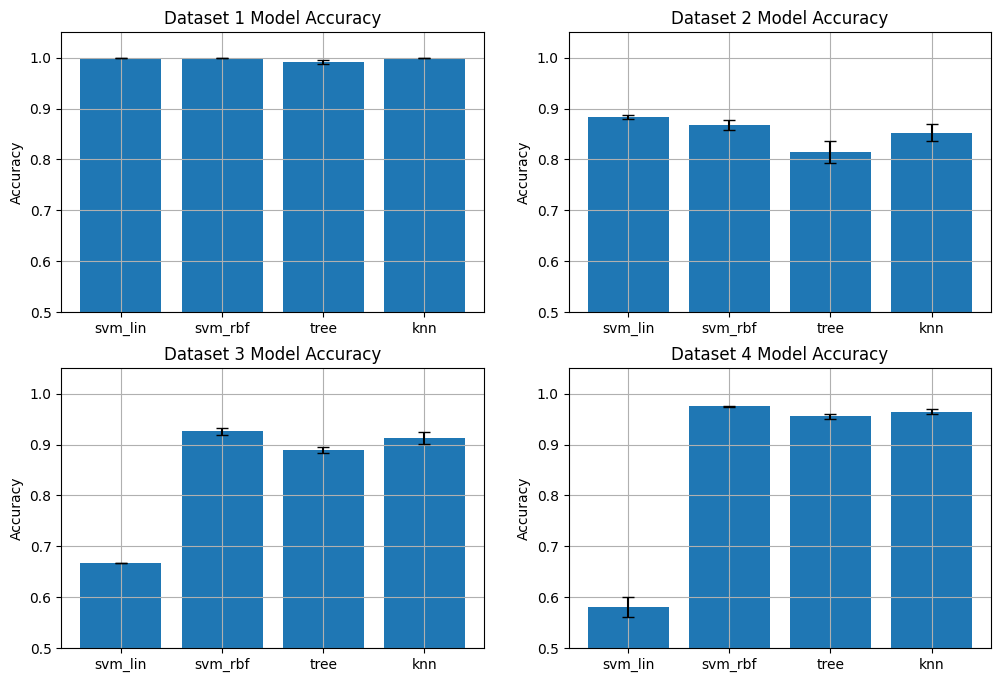

In [126]:
mdlist = ['svm_lin', 'svm_rbf', 'tree', 'knn']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, accuracy_result in enumerate(accuracy_5x2, start=1):
  means = [np.mean(accuracy_result[m]) for m in models]
  stds = [np.std(accuracy_result[m]) for m in models]
  ax = axes[i-1]
  ax.bar(mdlist, means, yerr=stds, capsize=4)
  ax.set_title(f"Dataset {i} Model Accuracy")
  ax.set_ylabel("Accuracy")
  ax.set_ylim(0.5,1.05)
  ax.grid()

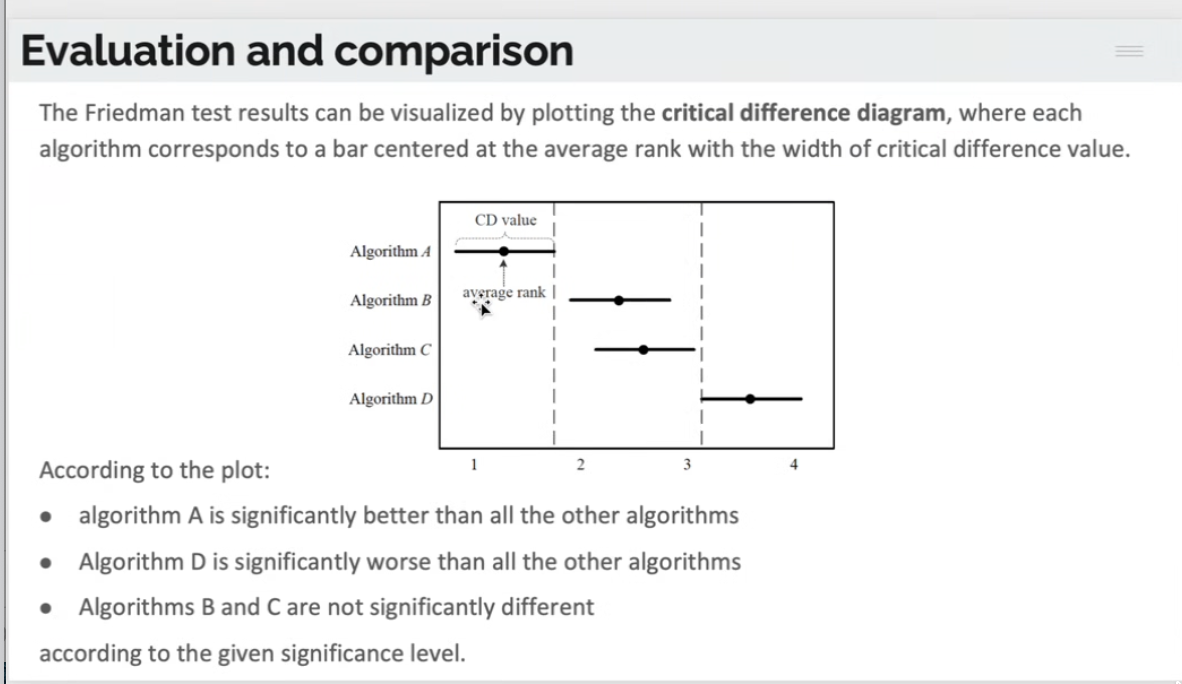